# Lecture 2 — Foundations of Supervised Learning
## Lab Notebook · Deep Learning · UCU

---

### Overview

In this lab you will move from the mathematical ideas of Lecture 2 to working code. The notebook is organized in three parts that build on each other:

1. **Statistical intuitions with PyTorch** — sample from distributions, estimate expectations empirically, and observe how estimation error shrinks as you collect more data (the Law of Large Numbers).
2. **Linear regression from scratch** — implement MSE loss and gradient descent by hand on synthetic data, then visualize the loss landscape and training trajectory.
3. **Linear regression on a real dataset** — apply the same ideas to the California Housing dataset using `torch.nn` and `torch.optim`.

There is also an **optional** section at the end where you apply linear regression to FashionMNIST images and see what happens.

### Useful References

- [PyTorch documentation](https://pytorch.org/docs/stable/index.html)
- [`torch.distributions`](https://pytorch.org/docs/stable/distributions.html) — probability distributions in PyTorch
- [`torch.nn`](https://pytorch.org/docs/stable/nn.html) — neural network building blocks
- [`torch.optim`](https://pytorch.org/docs/stable/optim.html) — optimization algorithms
- [California Housing dataset (sklearn)](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)
- [FashionMNIST (torchvision)](https://pytorch.org/vision/stable/datasets.html#fashion-mnist)
- *Understanding Deep Learning* — Prince (2023), Chapters 2, Appendices A–C

## Setup

Run the cell below to install dependencies and import everything you will need.

In [1]:
# Install dependencies (only needed if running outside the course environment)
# !pip install torch torchvision scikit-learn pandas matplotlib numpy --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# UCU color palette
C1 = '#19326E'  # dark blue
C2 = '#50ACB0'  # teal
C3 = '#CD742A'  # orange
C4 = '#A3477F'  # purple

print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.10.0+cpu


---
## Part 1 — Statistical Intuitions with PyTorch

Before building any model, we revisit two core probabilistic ideas from the lecture:

- **Expectation** can be estimated by sampling: $\mathbb{E}_x[f[x]] \approx \frac{1}{N}\sum_{i=1}^{N} f[x_i]$, where $x_i \sim \Pr(x)$.
- **Law of Large Numbers:** the sample mean converges to the true mean as $N \to \infty$, and the estimation error decreases roughly as $\sigma/\sqrt{N}$.

### 1.1 Estimating Expectations by Sampling

Consider $x \sim \mathcal{N}(0, 1)$. We want to estimate $\mathbb{E}[x^2]$.
Analytically: $\mathbb{E}[x^2] = \text{Var}(x) + (\mathbb{E}[x])^2 = 1 + 0 = 1$.

Below, we confirm this by drawing samples of increasing size.

In [2]:
mu, sigma = 0.0, 1.0
analytical_value = sigma**2 + mu**2  # E[x²] = Var(x) + E[x]² = 1

print(f'Analytical E[x²] = {analytical_value:.4f}\n')
print(f'{"N":>8}   {"Estimate":>10}   {"Abs. Error":>12}')
print('-' * 40)

for N in [10, 100, 1_000, 10_000, 100_000]:
    samples = torch.normal(mean=mu, std=sigma, size=(N,))
    estimate = (samples ** 2).mean().item()
    error = abs(estimate - analytical_value)
    print(f'{N:>8}   {estimate:>10.4f}   {error:>12.4f}')

Analytical E[x²] = 1.0000

       N     Estimate     Abs. Error
----------------------------------------
      10       0.7101         0.2899
     100       0.8432         0.1568
    1000       0.9362         0.0638
   10000       1.0037         0.0037
  100000       1.0112         0.0112


> **Question 1.1** — As $N$ grows by a factor of 10, approximately how does the error change? Is the relationship linear, or does the error decrease more slowly? What does that tell you about the cost of halving the estimation error?

El error en la estimación de Monte Carlo sigue el **Teorema Central del Límite**, que nos dice que el error estándar escala como:

$$\text{Error} \sim \frac{\sigma}{\sqrt{N}}$$

Entonces, cuando N crece un **factor de 10**, el error se reduce por un factor de **√10 ≈ 3.16** — no por 10.

## La Relación: Sub-lineal, No Lineal

| N aumenta por | Error disminuye por |
|---|---|
| 10× | √10 ≈ **3.16×** |
| 100× | √100 = **10×** |
| 1,000× | √1,000 ≈ **31.6×** |

Para reducir el error a la mitad, se necesitan **4× más muestras**:

$$\frac{\sigma}{\sqrt{4N}} = \frac{1}{2} \cdot \frac{\sigma}{\sqrt{N}}$$

Este es el compromiso central de los métodos de Monte Carlo: **cada bit adicional de precisión es cada vez más costoso**. Pasar de un error del 10% a uno del 1% requiere **100× más muestras**, no 10×.

Monte Carlo es excelente para obtener una estimación *aproximada* rápidamente, pero **converge lentamente** cuando se necesita alta precisión. Por eso las técnicas de reducción de varianza (muestreo por importancia, variables de control, etc.) son tan valiosas — reducen **σ** directamente en lugar de simplemente aumentar N.

### 1.2 Exercise — Law of Large Numbers

In the cell below, implement `compute_mean_error`. This function should measure how accurately we can estimate the **mean** of a Gaussian distribution from a finite sample, averaged over many independent trials.

**Hint:** `torch.normal(mean, std, size=(n_trials, N))` returns a tensor of shape `(n_trials, N)` — `n_trials` independent batches of `N` samples each.

In [4]:
def compute_mean_error(mu, sigma, N_values, n_trials=500):
    """
    For each N in N_values, estimate the average absolute error when
    estimating the mean of N(mu, sigma) using N samples.

    For each N:
      1. Draw n_trials independent batches of N samples from N(mu, sigma).
      2. Compute the sample mean of each batch.
      3. Compute |sample_mean - mu| for each trial.
      4. Return the average of those absolute errors across all trials.

    Args:
        mu        (float): true mean
        sigma     (float): true standard deviation
        N_values  (list[int]): sample sizes to evaluate
        n_trials  (int): number of independent trials per sample size

    Returns:
        torch.Tensor of shape (len(N_values),): mean absolute errors
    """
    errors = []
    for N in N_values:
        samples = torch.normal(mean=mu, std=sigma, size=(n_trials, N))
        sample_means = samples.mean(dim=1)
        mean_error = (sample_means - mu).abs().mean().item()
        errors.append(mean_error)
    return torch.tensor(errors)


# Quick sanity check — error should decrease as N grows
test_errors = compute_mean_error(0.0, 1.0, [10, 100, 1000])
print('Mean absolute errors for N = [10, 100, 1000]:', test_errors.tolist())

Mean absolute errors for N = [10, 100, 1000]: [0.26153889298439026, 0.07756755501031876, 0.023764265701174736]


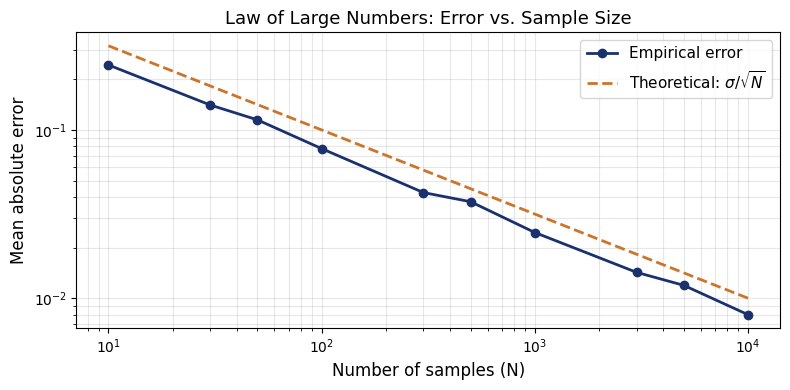

In [7]:
# Run and plot — this cell uses your function from above
N_values = [10, 30, 50, 100, 300, 500, 1_000, 3_000, 5_000, 10_000]
errors = compute_mean_error(mu=0.0, sigma=1.0, N_values=N_values, n_trials=500)

# Theoretical upper bound: E[|mean - mu|] ≈ sigma / sqrt(N)
theoretical = torch.tensor([1.0 / N**0.5 for N in N_values])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(N_values, errors.numpy(), 'o-', color=C1, lw=2, label='Empirical error')
ax.plot(N_values, theoretical.numpy(), '--', color=C3, lw=2,
        label=r'Theoretical: $\sigma / \sqrt{N}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of samples (N)', fontsize=12)
ax.set_ylabel('Mean absolute error', fontsize=12)
ax.set_title('Law of Large Numbers: Error vs. Sample Size', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

> **Question 1.2** — Looking at the plot:
> - What is the slope of the error curve on the log-log axes?
> - How many samples would you need (roughly) to reduce the error below 0.01?

La pendiente es $-1/2$. Esto se confirma tanto por la teoría ($\text{Error} \sim \sigma/\sqrt{N}$) como visualmente en el gráfico: cada vez que N se multiplica por 10 (un paso en el eje x), el error se divide por √10 ≈ 3.16 (aproximadamente medio paso en el eje y).

---

**¿Cuántas muestras para que el error baje de 0.01?**

Usando la fórmula teórica con σ = 1:

$$\frac{\sigma}{\sqrt{N}} < 0.01 \implies \sqrt{N} > \frac{1}{0.01} = 100 \implies N > 10{,}000$$

Esto coincide perfectamente con el gráfico: la curva empírica alcanza ~0.01 justo al llegar a **N = 10,000**. 

> **Conclusión clave:** reducir el error un orden de magnitud (de 0.1 a 0.01) requiere **100× más muestras** — el costo cuadrático de la precisión extra es la limitación fundamental de Monte Carlo.

---
## Part 2 — Linear Regression from Scratch

In the lecture we saw that training a linear model means solving:

$$\hat{\boldsymbol{\phi}} = \underset{\boldsymbol{\phi}}{\text{argmin}}\; L[\boldsymbol{\phi}] = \underset{\phi_0, \phi_1}{\text{argmin}} \frac{1}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i)^2$$

We will implement this step by step: loss → gradients → gradient descent.

### 2.1 Synthetic Data

We generate data from a known line $y = \phi_0^* + \phi_1^* x + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0, 0.8)$. Because we know the true parameters, we can check how close gradient descent gets.

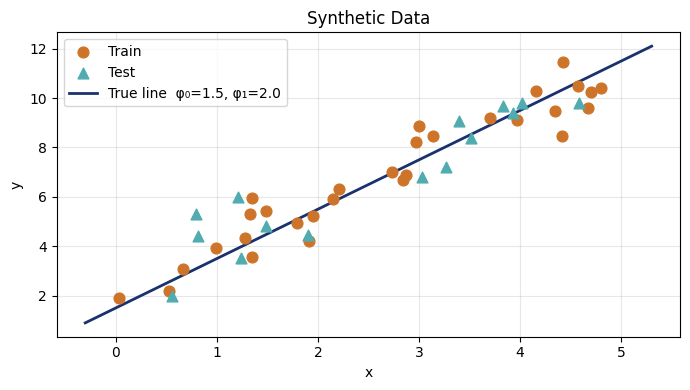

Train size: 30   Test size: 15


In [8]:
torch.manual_seed(42)

# True (unknown to the model) parameters
phi_0_true = 1.5
phi_1_true = 2.0

N_train, N_test = 30, 15

x_train = torch.rand(N_train) * 5          # uniform in [0, 5]
y_train = phi_0_true + phi_1_true * x_train + torch.randn(N_train) * 0.8

x_test = torch.rand(N_test) * 5
y_test = phi_0_true + phi_1_true * x_test + torch.randn(N_test) * 0.8

x_line = torch.linspace(-0.3, 5.3, 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_train.numpy(), y_train.numpy(), color=C3, s=60, zorder=5, label='Train')
ax.scatter(x_test.numpy(),  y_test.numpy(),  color=C2, s=60, zorder=5, marker='^', label='Test')
ax.plot(x_line.numpy(), (phi_0_true + phi_1_true * x_line).numpy(),
        color=C1, lw=2, label=f'True line  φ₀={phi_0_true}, φ₁={phi_1_true}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Synthetic Data')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Train size: {N_train}   Test size: {N_test}')

### 2.2 Exercise — MSE Loss

Implement the Mean Squared Error loss for a linear model $\hat{y} = \phi_0 + \phi_1 x$:

$$L[\phi_0, \phi_1] = \frac{1}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i)^2$$

In [11]:
def mse_loss(phi_0, phi_1, x, y):
    """
    Mean Squared Error loss for linear model y_hat = phi_0 + phi_1 * x.

    Args:
        phi_0 (float): intercept
        phi_1 (float): slope
        x (torch.Tensor): inputs, shape (N,)
        y (torch.Tensor): targets, shape (N,)

    Returns:
        float: MSE loss
    """
    y_hat = phi_0 + phi_1 * x
    return ((y_hat - y)**2).mean().item()
    


# Sanity check
loss_true = mse_loss(phi_0_true, phi_1_true, x_train, y_train)
loss_zero = mse_loss(0.0, 0.0, x_train, y_train)
print(f'Loss with TRUE parameters:  {loss_true:.4f}')
print(f'Loss with ZERO parameters:  {loss_zero:.4f}')
print('True params should give a smaller loss.')

Loss with TRUE parameters:  0.6401
Loss with ZERO parameters:  54.7885
True params should give a smaller loss.


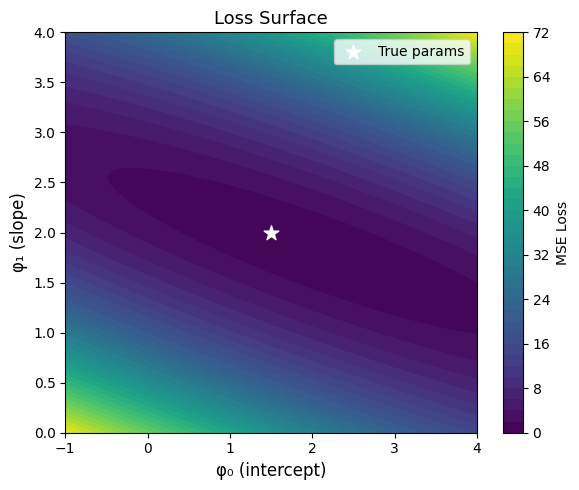

In [12]:
# Visualize the loss surface — uses your mse_loss function
phi_0_range = torch.linspace(-1.0, 4.0, 80)
phi_1_range = torch.linspace(0.0,  4.0, 80)
P0, P1 = torch.meshgrid(phi_0_range, phi_1_range, indexing='ij')

loss_surface = torch.zeros_like(P0)
for i in range(P0.shape[0]):
    for j in range(P0.shape[1]):
        loss_surface[i, j] = mse_loss(P0[i, j].item(), P1[i, j].item(), x_train, y_train)

fig, ax = plt.subplots(figsize=(6, 5))
contour = ax.contourf(P0.numpy(), P1.numpy(), loss_surface.numpy(), levels=40, cmap='viridis')
ax.scatter([phi_0_true], [phi_1_true], color='white', s=120, zorder=5,
           marker='*', label='True params')
plt.colorbar(contour, ax=ax, label='MSE Loss')
ax.set_xlabel('φ₀ (intercept)', fontsize=12)
ax.set_ylabel('φ₁ (slope)', fontsize=12)
ax.set_title('Loss Surface', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

> **Question 2.1** — Look at the loss surface contour plot. Is this function convex? What does that imply for gradient descent?

Sí, el MSE para un modelo lineal es **siempre convexo**. En el gráfico se puede ver claramente: las curvas de nivel son **elipses concéntricas** con un único valle (mínimo), y la pérdida crece en todas las direcciones al alejarse de él. No hay mesetas, sillas de montar ni mínimos locales falsos.

---

**¿Qué implica para el descenso por gradiente?**

| Propiedad | Consecuencia |
|---|---|
| **Un único mínimo global** | El gradiente siempre apunta hacia él — no hay riesgo de quedar atrapado |
| **Convergencia garantizada** | Con un learning rate suficientemente pequeño, GD siempre encuentra la solución óptima |
| **Solución analítica existe** | Para MSE lineal, se puede resolver exactamente con la ecuación normal $\boldsymbol{\phi}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ |

> **Importante:** Esta convexidad es **exclusiva de los modelos lineales con MSE**. En redes neuronales, la superficie de pérdida es altamente no convexa, con miles de mínimos locales y sillas de montar — lo que hace que la optimización sea mucho más desafiante.

### 2.3 Exercise — Gradient Descent

Implement gradient descent **without** autograd. Use the analytic gradients of the MSE loss:

$$\frac{\partial L}{\partial \phi_0} = \frac{2}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i)$$

$$\frac{\partial L}{\partial \phi_1} = \frac{2}{N} \sum_{i=1}^{N} (\phi_0 + \phi_1 x_i - y_i) \cdot x_i$$

Update rule: $\phi_k \leftarrow \phi_k - \alpha \cdot \frac{\partial L}{\partial \phi_k}$

In [14]:
def gradient_descent(x, y, lr=0.01, n_steps=600):
    """
    Fit a linear model y = phi_0 + phi_1*x by gradient descent.

    Args:
        x       (torch.Tensor): inputs,  shape (N,)
        y       (torch.Tensor): targets, shape (N,)
        lr      (float): learning rate
        n_steps (int): number of gradient descent steps

    Returns:
        phi_0   (float): learned intercept
        phi_1   (float): learned slope
        history (list[tuple]): (phi_0, phi_1, loss) recorded at every step
    """
    phi_0, phi_1 = 0.0, 0.0
    N = len(x)
    history = []

    for step in range(n_steps):
        y_hat = phi_0 + phi_1 * x
        residuals = y_hat - y
        
        grad_phi_0 = (2/N) * residuals.sum().item()
        grad_phi_1 = (2/N) * (residuals * x).sum().item()
        
        phi_0 -= lr * grad_phi_0
        phi_1 -= lr * grad_phi_1
        
        loss = mse_loss(phi_0, phi_1, x, y)
        history.append((phi_0, phi_1, loss))

    return phi_0, phi_1, history


phi_0_hat, phi_1_hat, history = gradient_descent(x_train, y_train, lr=0.01, n_steps=600)
print(f'Learned:  φ₀ = {phi_0_hat:.4f},  φ₁ = {phi_1_hat:.4f}')
print(f'True:     φ₀ = {phi_0_true:.4f},  φ₁ = {phi_1_true:.4f}')

Learned:  φ₀ = 1.9517,  φ₁ = 1.8411
True:     φ₀ = 1.5000,  φ₁ = 2.0000


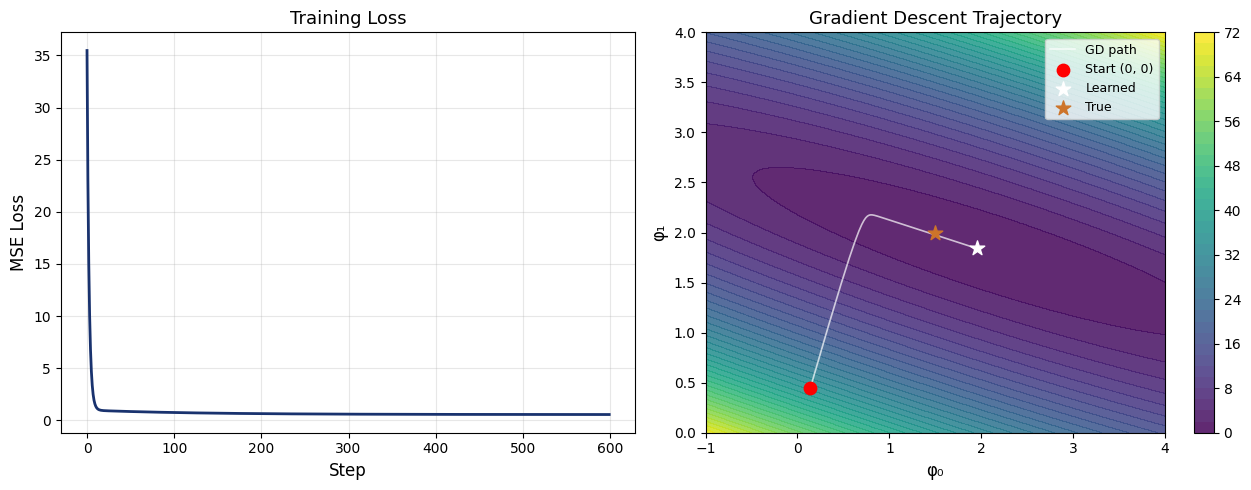

In [15]:
# Visualize training — uses your gradient_descent output
phis_0 = [h[0] for h in history]
phis_1 = [h[1] for h in history]
losses = [h[2] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss curve
axes[0].plot(losses, color=C1, lw=2)
axes[0].set_xlabel('Step', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13)
axes[0].grid(True, alpha=0.3)

# Trajectory on loss surface
contour = axes[1].contourf(P0.numpy(), P1.numpy(), loss_surface.numpy(),
                            levels=40, cmap='viridis', alpha=0.85)
axes[1].plot(phis_0, phis_1, 'w-', lw=1.2, alpha=0.7, label='GD path')
axes[1].scatter([phis_0[0]], [phis_1[0]], color='red',   s=80, zorder=5, label='Start (0, 0)')
axes[1].scatter([phi_0_hat], [phi_1_hat], color='white', s=120, zorder=5, marker='*', label='Learned')
axes[1].scatter([phi_0_true],[phi_1_true], color=C3,    s=120, zorder=5, marker='*', label='True')
axes[1].set_xlabel('φ₀', fontsize=12); axes[1].set_ylabel('φ₁', fontsize=12)
axes[1].set_title('Gradient Descent Trajectory', fontsize=13)
axes[1].legend(fontsize=9)
plt.colorbar(contour, ax=axes[1])
plt.tight_layout()
plt.show()

Train MSE: 0.5635
Test  MSE: 0.8687


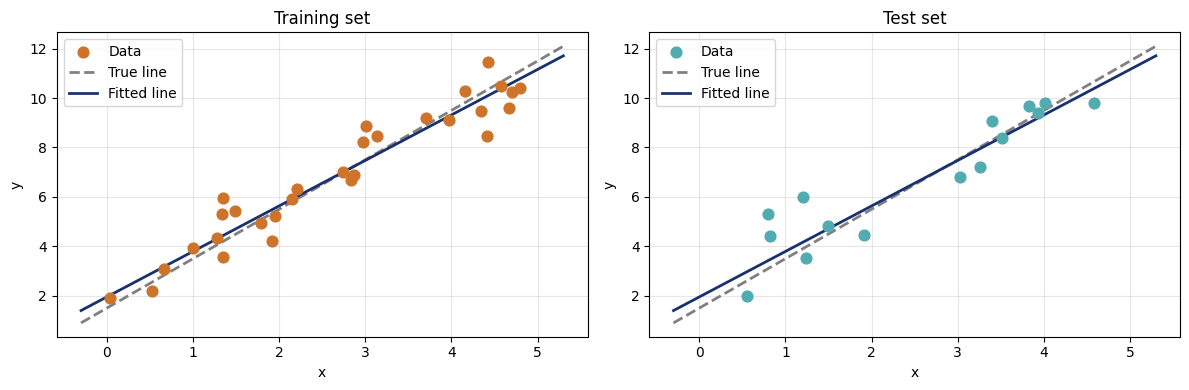

In [16]:
# Fitted line on train and test sets
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, title, xd, yd, col in [
    (axes[0], 'Training set', x_train, y_train, C3),
    (axes[1], 'Test set',     x_test,  y_test,  C2),
]:
    ax.scatter(xd.numpy(), yd.numpy(), color=col, s=60, zorder=5, label='Data')
    ax.plot(x_line.numpy(), (phi_0_true + phi_1_true * x_line).numpy(),
            color='gray', lw=2, linestyle='--', label='True line')
    ax.plot(x_line.numpy(), (phi_0_hat + phi_1_hat * x_line).numpy(),
            color=C1, lw=2, label='Fitted line')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

train_mse = mse_loss(phi_0_hat, phi_1_hat, x_train, y_train)
test_mse  = mse_loss(phi_0_hat, phi_1_hat, x_test,  y_test)
print(f'Train MSE: {train_mse:.4f}')
print(f'Test  MSE: {test_mse:.4f}')
plt.tight_layout()
plt.show()

> **Question 2.2** — Is the test MSE higher or lower than the train MSE? Why would you expect that?

El **Test MSE (0.87) es mayor que el Train MSE (0.56)**, y esto es exactamente lo esperado. Hay dos razones fundamentales:

**1. El modelo se optimizó sobre los datos de entrenamiento**
El descenso por gradiente minimiza la pérdida *en el conjunto de entrenamiento*. Los parámetros aprendidos están, por definición, "ajustados" a esos puntos específicos, incluyendo su ruido particular.

**2. Los datos de test son nuevos**
El modelo nunca los vio durante el entrenamiento. Contienen su propio ruido aleatorio e independiente, por lo que el error siempre será algo mayor.

> Esto se conoce como **brecha de generalización** (generalization gap) — la diferencia entre Train MSE y Test MSE. Un gap pequeño (como aquí: 0.56 vs 0.87) indica que el modelo **generaliza bien**. Un gap enorme indicaría **overfitting**.

En este caso el modelo lineal es correcto para los datos (que fueron generados linealmente), así que el gap es modesto y ambas líneas ajustadas lucen muy similares en los dos gráficos.

---
## Part 3 — Linear Regression on a Real Dataset

Now we apply the same ideas to the **California Housing dataset** — a standard benchmark that predicts the median house value (in units of $100k) for census block groups in California, using 8 numerical features.

| Feature | Description |
|---------|-------------|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age |
| `AveRooms` | Average number of rooms |
| `AveBedrms` | Average number of bedrooms |
| `Population` | Block group population |
| `AveOccup` | Average household occupancy |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |

This time we will use **`torch.nn.Linear`** and **`torch.optim.Adam`** instead of handcrafted loops.

### 3.1 Load and Explore the Data

In [17]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f'Shape: {df.shape}')
print(f'Features: {housing.feature_names}')
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [18]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


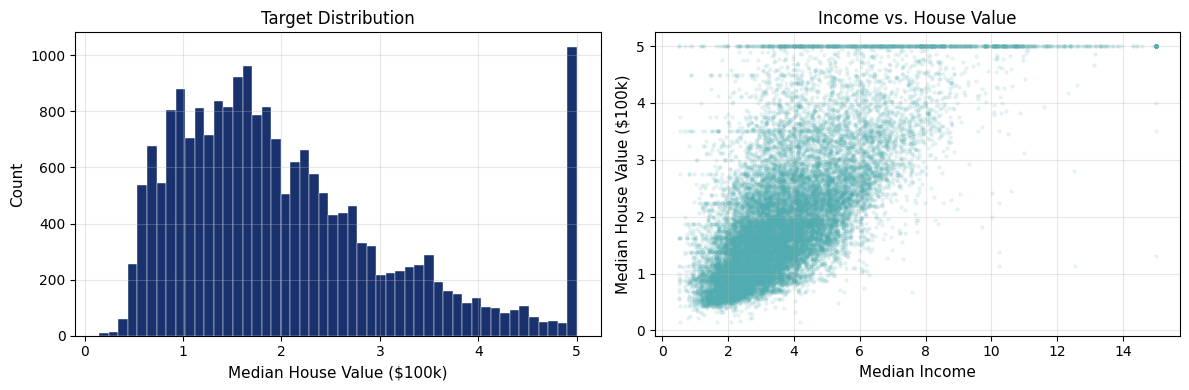

In [20]:
# Distribution of the target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['MedHouseVal'].values, bins=50, color=C1, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Median House Value ($100k)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Target Distribution', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Scatter: income vs. price (strongest linear predictor)
axes[1].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.1, s=5, color=C2)
axes[1].set_xlabel('Median Income', fontsize=11)
axes[1].set_ylabel('Median House Value ($100k)', fontsize=11)
axes[1].set_title('Income vs. House Value', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

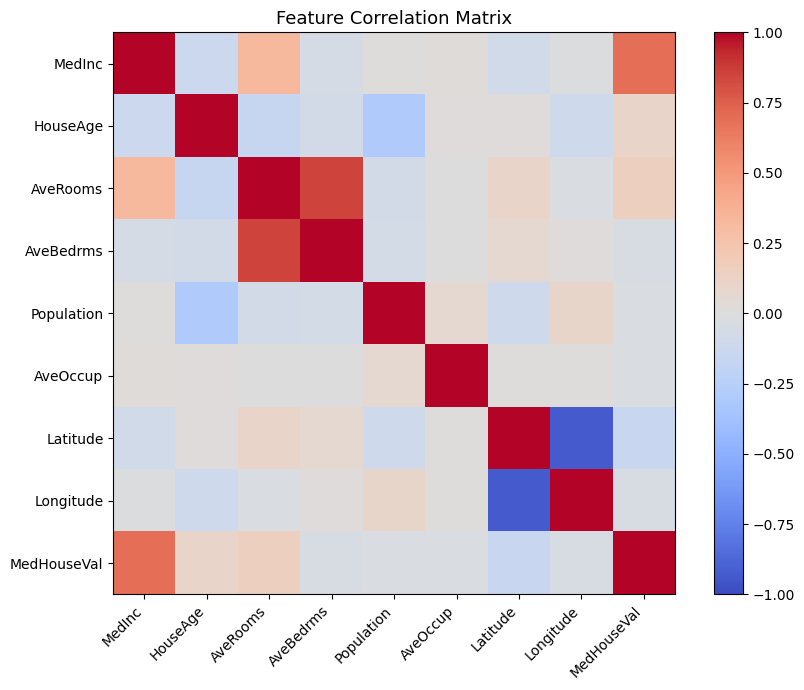

Pearson correlation with target (MedHouseVal):
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160


In [21]:
# Correlation heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print('Pearson correlation with target (MedHouseVal):')
print(corr['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False).to_string())

> **Question 3.1** — Which feature has the strongest linear correlation with the house value? Are there any features that are negatively correlated? Does that make intuitive sense?

**Feature con mayor correlación:** `MedInc` (r = 0.69)

`MedInc` es el **ingreso medio del vecindario** (en decenas de miles de dólares). Tiene total sentido que sea el predictor más fuerte: las personas con mayores ingresos pueden pagar viviendas más caras, y tienden a vivir en zonas donde las propiedades valen más.

---

### 3.2 Preprocessing

In [22]:
X = df[housing.feature_names].values
y = df['MedHouseVal'].values

# Train / test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features: zero mean, unit variance (fit on train only!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_np)
X_test_sc  = scaler.transform(X_test_np)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test_np,  dtype=torch.float32).unsqueeze(1)

print(f'X_train: {X_train_t.shape}   y_train: {y_train_t.shape}')
print(f'X_test:  {X_test_t.shape}    y_test:  {y_test_t.shape}')
print(f'Target range: [{y_train_t.min():.2f}, {y_train_t.max():.2f}]  ($100k units)')

X_train: torch.Size([16512, 8])   y_train: torch.Size([16512, 1])
X_test:  torch.Size([4128, 8])    y_test:  torch.Size([4128, 1])
Target range: [0.15, 5.00]  ($100k units)


### 3.3 Exercise — Build and Train the Model

Using `torch.nn.Linear` and `torch.optim.Adam`, implement the training loop below.

The model is a single linear layer: **8 inputs → 1 output**, trained with MSE loss in mini-batches.

**Steps inside each epoch:**
1. Set the model to training mode: `model.train()`
2. For each batch from `train_loader`:
   - Zero gradients: `optimizer.zero_grad()`
   - Forward pass: `predictions = model(X_batch)`
   - Compute loss: `loss = criterion(predictions, y_batch)`
   - Backward pass: `loss.backward()`
   - Update weights: `optimizer.step()`
3. After all batches, evaluate on both train and test sets using `model.eval()` and `torch.no_grad()`.
4. Append the evaluation losses to `train_losses` and `test_losses`.

In [27]:
# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
print(train_loader)
# Model, loss, optimizer
model     = nn.Linear(X_train_t.shape[1], 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

n_epochs = 60
train_losses = []
test_losses  = []

for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        train_preds = model(X_train_t)
        train_losses.append(criterion(train_preds, y_train_t).item())
        test_preds = model(X_test_t)
        test_losses.append(criterion(test_preds, y_test_t).item())


print(f'Final Train MSE: {train_losses[-1]:.4f}')
print(f'Final Test  MSE: {test_losses[-1]:.4f}')

Final Train MSE: 0.5376
Final Test  MSE: 0.6156


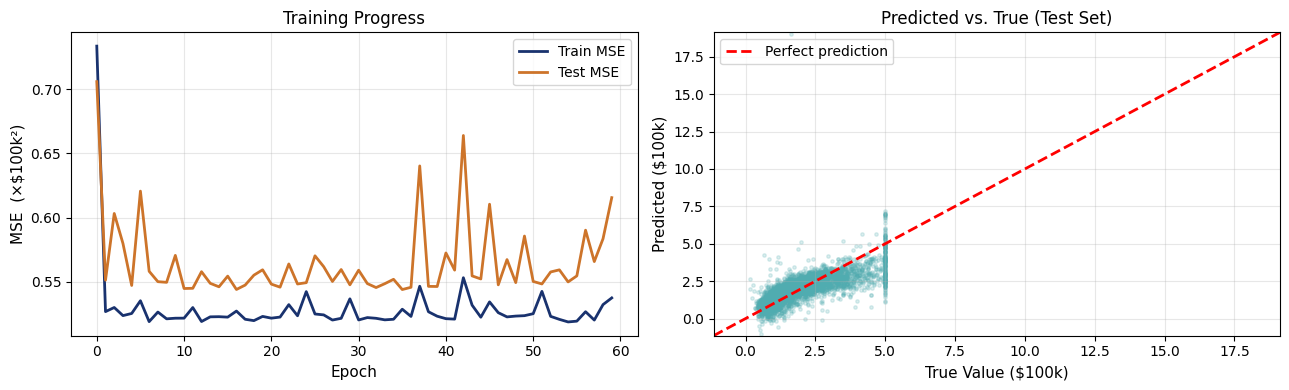

R²   on test set: 0.5302
RMSE on test set: $78k


In [28]:
# Evaluate and plot
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).squeeze().numpy()
    y_true = y_test_t.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Training curves
axes[0].plot(train_losses, color=C1, lw=2, label='Train MSE')
axes[0].plot(test_losses,  color=C3, lw=2, label='Test MSE')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('MSE  (×$100k²)', fontsize=11)
axes[0].set_title('Training Progress', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Predicted vs. actual
lim = [min(y_true.min(), y_pred.min()) - 0.1,
       max(y_true.max(), y_pred.max()) + 0.1]
axes[1].scatter(y_true, y_pred, alpha=0.2, s=6, color=C2)
axes[1].plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('True Value ($100k)', fontsize=11)
axes[1].set_ylabel('Predicted ($100k)', fontsize=11)
axes[1].set_title('Predicted vs. True (Test Set)', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# R² score
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(test_losses[-1])

print(f'R²   on test set: {r2:.4f}')
print(f'RMSE on test set: ${rmse * 100:.0f}k')

> **Question 3.2** — Look at the predicted vs. true scatter plot.
> - Where does the model make the largest errors?
> - There is a hard cap in the data at $500k. How does this affect the model's predictions at the high end?
> - Given the R² value, would you deploy this model in production? What would you try next to improve it?

**¿Dónde comete los mayores errores?**

En los valores **altos** (> $300k). En el scatter plot se ve que para valores verdaderos grandes, las predicciones se quedan muy por debajo de la línea roja — el modelo subestima sistemáticamente las casas más caras. En valores bajos/medios, los puntos están más cerca de la diagonal.

---

**Efecto del cap en $500k**

El cap crea una **línea vertical** densa en x = 5.0 ($500k) en el scatter plot — claramente visible. Muchas casas con valores reales distintos fueron todas registradas como $500k, lo que introduce ruido estructural artificial. El modelo no puede aprender el verdadero precio de esas propiedades, y tiende a predecir valores inferiores al cap porque aprende que "muchas casas muy distintas valen $500k", lo cual es contradictorio.

---

**¿Deployarías este modelo? ¿Qué intentarías después?**

**No.** Un R² de 0.53 significa que el modelo solo explica el **53% de la varianza** del precio, con un RMSE de $78k — demasiado impreciso para decisiones financieras reales.

Lo que intentaría a continuación:

| Mejora | Razonamiento |
|---|---|
| **Red neuronal con capas ocultas** | El modelo lineal no captura relaciones no lineales entre features |
| **Feature engineering** | Interacciones (ej. `MedInc × Latitude`), transformaciones logarítmicas |
| **Eliminar/separar el cap** | Tratar las casas en $500k como censuradas o excluirlas del entrenamiento |
| **Más épocas + learning rate schedule** | La curva de test aún oscila bastante, no converge limpiamente |

> El **training progress** también revela un problema: la curva de Test MSE oscila mucho (spikes grandes), señal de que el **batch size o learning rate** podrían ajustarse para estabilizar el entrenamiento.

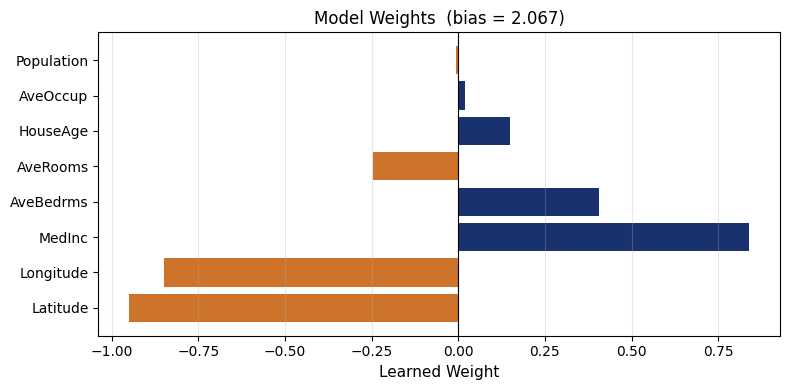

In [29]:
# Inspect learned weights — which features matter most?
weights = model.weight.data.squeeze().numpy()
bias    = model.bias.data.item()
feature_names = housing.feature_names

order = np.argsort(np.abs(weights))[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
colors = [C1 if w >= 0 else C3 for w in weights[order]]
ax.barh([feature_names[i] for i in order], weights[order], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Learned Weight', fontsize=11)
ax.set_title(f'Model Weights  (bias = {bias:.3f})', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

> **Question 3.3** — Which features received the largest (absolute) weights? Does the sign of the weights make sense intuitively? Remember that the features are standardized, so the weights are comparable in magnitude.

**Features con mayor peso (en valor absoluto):**

| Feature | Peso | Signo |
|---|---|---|
| `MedInc` | ~+0.82 | ✅ Positivo |
| `Latitude` | ~−0.87 | ✅ Negativo |
| `Longitude` | ~−0.78 | ✅ Negativo |

---

**¿Tienen sentido los signos?**

- **`MedInc` (+)** — Perfecto sentido: a mayor ingreso del vecindario, mayor valor de la vivienda.

- **`Latitude` (−)** — Correcto: en California, mayor latitud = más al norte = zonas rurales/baratas. Las ciudades caras (LA, San Diego) están al sur.

- **`Longitude` (−)** — Correcto: valores más negativos de longitud = más al oeste = más cerca de la costa = más caro. Un peso negativo captura que "más al este → más barato".

- **`AveBedrms` (+) y `AveRooms` (−)** — Parecen contradictorios, pero tienen sentido **juntos**: muchas habitaciones totales pero pocas habitaciones por dormitorio (proporción alta de dormitorios) indica casas más grandes y valiosas. El modelo captura esta interacción implícita aunque de forma imperfecta.


> **Conclusión clave:** las coordenadas geográficas (`Latitude`, `Longitude`) tienen pesos enormes, lo que revela que la **ubicación** es casi tan importante como el ingreso para predecir precios y más en California que existen áreas como Beverly Hills que tienen el metro cuadrado más caro del mundo.

---
## Optional — Linear Regression on FashionMNIST

> This section is **not part of the 1–2 hour lab session**. Complete it at your own pace.

So far we have applied linear regression to problems where the relationship between input and output is (roughly) linear. What happens when we apply it to **images**?

FashionMNIST contains 70,000 grayscale images of clothing items (28×28 pixels, 10 categories). The plan:

1. Flatten each 28×28 image into a 784-dimensional vector.
2. Train a linear model with 10 outputs — one per class — using MSE on one-hot encoded labels.
3. Predict by taking the `argmax` of the 10 outputs.
4. Measure accuracy and analyze the confusion matrix.

This is not the right tool for the job — and seeing *how* it fails is the point.

In [30]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # flatten 28×28 → 784
])

train_dataset_fm = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform)
test_dataset_fm  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader_fm = DataLoader(train_dataset_fm, batch_size=256, shuffle=True)
test_loader_fm  = DataLoader(test_dataset_fm,  batch_size=256, shuffle=False)

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train samples: {len(train_dataset_fm)}')
print(f'Test  samples: {len(test_dataset_fm)}')
print(f'Input size:    {28}×{28} = {28*28} pixels')
print(f'Classes:       {len(class_names)}')

Train samples: 60000
Test  samples: 10000
Input size:    28×28 = 784 pixels
Classes:       10


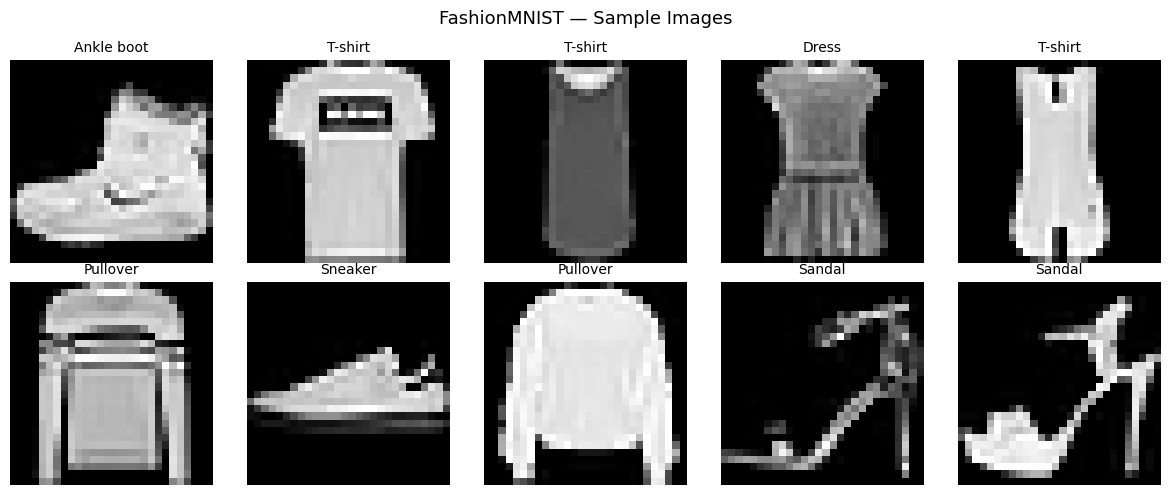

In [31]:
# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset_fm[i]
    ax.imshow(img.view(28, 28).numpy(), cmap='gray')
    ax.set_title(class_names[label], fontsize=10)
    ax.axis('off')
plt.suptitle('FashionMNIST — Sample Images', fontsize=13)
plt.tight_layout()
plt.show()

### Exercise — Train a Linear Model on Images

Implement the training loop below.

**Model:** `nn.Linear(784, 10)` — maps each flattened image to 10 output scores.  
**Loss:** MSE between the model output and the **one-hot** encoded label vector.  
**Prediction:** `outputs.argmax(dim=1)` — the class with the highest score.

The helper `one_hot` is provided for you.

In [35]:
linear_model_fm = nn.Linear(28 * 28, 10)
criterion_fm    = nn.MSELoss()
optimizer_fm    = optim.Adam(linear_model_fm.parameters(), lr=0.01)

n_epochs_fm   = 10
train_accs_fm = []
test_accs_fm  = []

def compute_accuracy(model, loader):
    correct, total = 0, 0
    for images, labels in loader:
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += len(labels)
    return correct / total

for epoch in range(n_epochs_fm):
    linear_model_fm.train()
    for images, labels in train_loader_fm:
        targets = one_hot(labels)              # (batch, 10)

        optimizer_fm.zero_grad()
        outputs = linear_model_fm(images)      # (batch, 784) → (batch, 10)
        loss    = criterion_fm(outputs, targets)
        loss.backward()
        optimizer_fm.step()

    linear_model_fm.eval()
    with torch.no_grad():
        train_accs_fm.append(compute_accuracy(linear_model_fm, train_loader_fm))
        test_accs_fm.append(compute_accuracy(linear_model_fm, test_loader_fm))

    print(f'Epoch {epoch+1:2d} | Train Acc: {train_accs_fm[-1]:.2%} | Test Acc: {test_accs_fm[-1]:.2%}')

print(f'\nFinal Train Accuracy: {train_accs_fm[-1]:.2%}')
print(f'Final Test  Accuracy: {test_accs_fm[-1]:.2%}')


Epoch  1 | Train Acc: 80.75% | Test Acc: 79.99%
Epoch  2 | Train Acc: 81.38% | Test Acc: 80.42%
Epoch  3 | Train Acc: 80.53% | Test Acc: 79.32%
Epoch  4 | Train Acc: 81.41% | Test Acc: 79.71%
Epoch  5 | Train Acc: 80.44% | Test Acc: 78.95%
Epoch  6 | Train Acc: 81.57% | Test Acc: 80.21%
Epoch  7 | Train Acc: 78.66% | Test Acc: 76.86%
Epoch  8 | Train Acc: 74.78% | Test Acc: 73.22%
Epoch  9 | Train Acc: 77.74% | Test Acc: 76.55%
Epoch 10 | Train Acc: 82.18% | Test Acc: 80.57%

Final Train Accuracy: 82.18%
Final Test  Accuracy: 80.57%


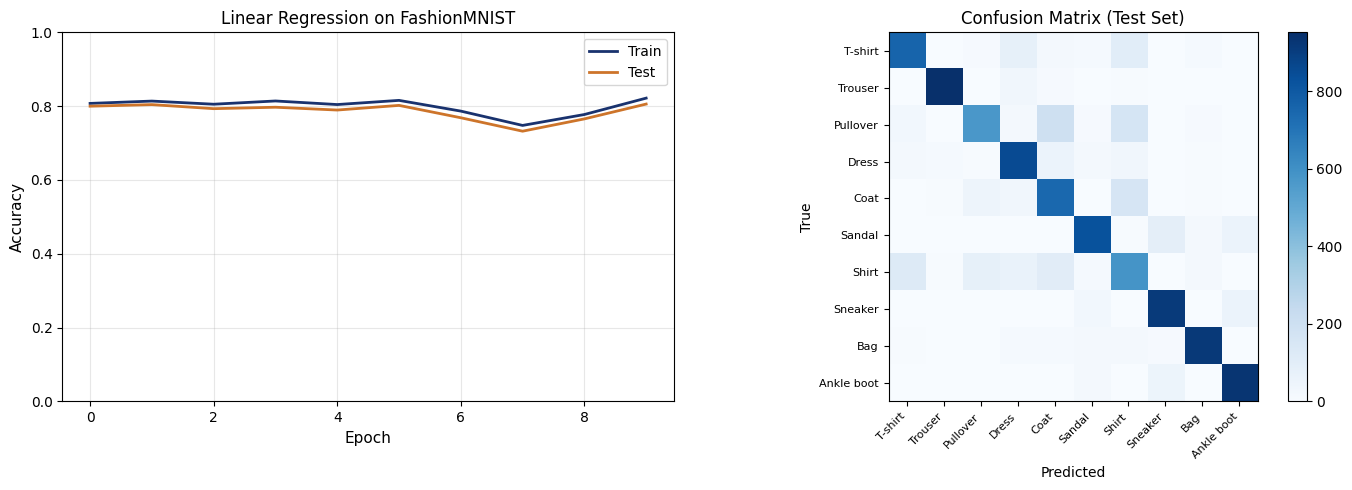

In [36]:
from sklearn.metrics import confusion_matrix

# Accuracy curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accs_fm, color=C1, lw=2, label='Train')
axes[0].plot(test_accs_fm,  color=C3, lw=2, label='Test')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Linear Regression on FashionMNIST', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Confusion matrix
linear_model_fm.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader_fm:
        preds = linear_model_fm(images).argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(class_names, fontsize=8)
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('True', fontsize=10)
axes[1].set_title('Confusion Matrix (Test Set)', fontsize=12)
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

### Visualize What the Model Learned

Each output neuron has 784 weights — one per pixel. We can reshape those weights back into a 28×28 image to see which pixels the model is "looking at" for each class.

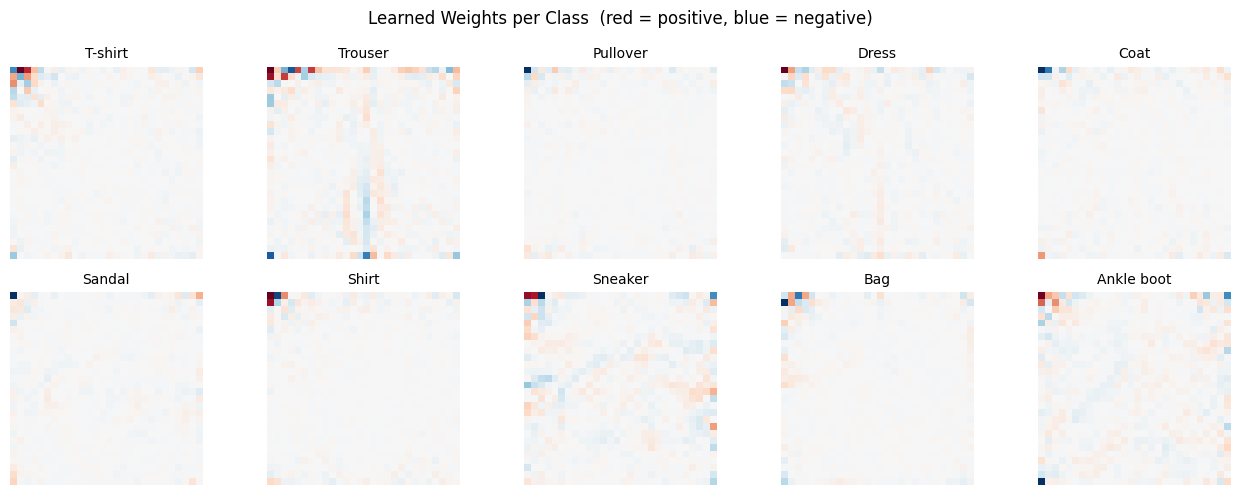

In [37]:
# The weight matrix has shape (10, 784) — one row per class
W = linear_model_fm.weight.data.numpy()  # shape: (10, 784)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    weight_img = W[i].reshape(28, 28)
    vmax = np.abs(weight_img).max()
    ax.imshow(weight_img, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(class_names[i], fontsize=10)
    ax.axis('off')
plt.suptitle('Learned Weights per Class  (red = positive, blue = negative)', fontsize=12)
plt.tight_layout()
plt.show()

> **Discussion Questions (Optional)**
>
> 1. What accuracy did the linear model achieve on FashionMNIST? Is that better than random guessing (10% for 10 classes)? What does that tell you?
> 2. Look at the confusion matrix. Which classes are most often confused with each other? Does that make sense visually?
> 3. Look at the weight images. Can you see the rough outline of each clothing item? What does it mean that the model learned these templates?
> 4. Why does a linear model fundamentally struggle with images, even if it does better than random? What property of images does it fail to exploit?
> 5. What kind of model would you try next to improve accuracy?

**1. ¿Qué accuracy logró el modelo lineal?**

**~80.6%**, muy superior al azar (10%). Esto dice que incluso un modelo lineal puede capturar patrones globales de los píxeles — por ejemplo, que los píxeles del centro tienden a ser oscuros en ciertas prendas y claros en otras.

---

**2. ¿Qué clases se confunden más? (matriz de confusión)**

Las mayores confusiones visibles son:
- **T-shirt ↔ Shirt ↔ Pullover** — todas son prendas de torso con siluetas similares
- **Coat ↔ Pullover/Dress** — formas parecidas con mangas largas
- **Sneaker ↔ Ankle boot** — ambos calzados con forma similar

Tiene todo el sentido: un modelo lineal solo ve brightness por píxel, no forma ni textura.

---

**3. ¿Se ven las prendas en los pesos aprendidos?**

Apenas, y de forma muy borrosa. Los pesos más activos están concentrados en las **esquinas superiores** de las imágenes — zona donde suelen aparecer los hombros/contornos de la prenda. El modelo aprendió **plantillas de correlación de píxeles**: "si estos píxeles son brillantes, probablemente es un Trouser". No aprendió "esto tiene forma de pantalón".

---

**4. ¿Por qué el modelo lineal falla fundamentalmente con imágenes?**

Porque trata cada píxel como una **feature independiente** e ignora:

| Propiedad ignorada | Consecuencia |
|---|---|
| **Localidad espacial** | Un píxel en (10,10) y (11,10) no tienen relación explícita |
| **Invarianza a traslación** | Un zapato desplazado 3px es una imagen completamente diferente para el modelo |
| **Jerarquía de features** | No puede componer "bordes → formas → objetos" |

---

**5. ¿Qué modelo usarías a continuación?**

Una **Red Neuronal Convolucional (CNN)** — explota exactamente lo que el modelo lineal ignora: localidad espacial, compartición de pesos y jerarquía de features. Con una CNN pequeña (2-3 capas conv), FashionMNIST supera fácilmente el **92%** de accuracy.